In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importando o arquivo Excel
df = pd.read_excel('[FM2S]Lista_Exercícios_1.xlsx', sheet_name='05.Acidentes') 
df.head()

,REGISTRO,DATA de admissão na empresa,Função,HORAS do A.T,HORAS trabalhadas,Estado civil,Data de nascimento,DATA do acidente,DIA da semana,TIPO de acidente,Tipo de acidente,ÁREA/LOCAL DE trabalho do acidentado,DESCRIÇÃO DO A.T.,DIAS perdidos,NATUREZA LESÃO,AGENTE DA LESÃO,PARTE DO corpo atingida
0,1,22.03.11,Ajud. Montagem,06:35:00,0,Solteiro,1992-11-11 00:00:00,2012-02-13,SEGUNDA,TRAJETO,NaN,Montagem,"Transitando moto, derrapou e caiu, escoriações...",0,Escoriações,Veiculo,"Torax, braço e perna"
1,2,23.05.88,Lider mecanico,15:00:00,07:00:00,Casado,1967-02-24 00:00:00,2012-03-02,SEXTA,ASA,NaN,Manutenção,"Utiliz. alavanca em manut. injetora, escapou a...",0,Contusão,Ferramenta manual,Cabeça
2,3,22.03.11,Mont. III,17:15:00,0,Casado,1980-03-12 00:00:00,2012-03-24,SEXTA,TRAJETO,NaN,Montagem,"Transitando moto, derrapou e caiu, escoriações...",0,Escoriações,Veiculo,Braço
3,4,23.03.10,Aux. Expedição,10:00:00,03:00:00,Solteiro,1991-06-09 00:00:00,2012-04-17,TERÇA,ACA,NaN,Expedição,"Ao descer palete, pisou no solo sentiu dores t...",2,Entorse,Piso,Tornozelo
4,5,27.09.10,Ajud. Montagem,09:00:00,02:15:00,Solteiro,1991-12-16 00:00:00,2012-04-24,TERÇA,ACA,NaN,Montagem,Ao acionar rebidadeira deixou 2o dedo direito ...,4,Escoriações,Maquina,Dedos


C:\Users\embras\AppData\Local\Temp\ipykernel_5628\4021670409.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=frequencia_tipos, x='Quantidade', y='TIPO de acidente', palette='Blues_r', ax=axes[0, 1])
C:\Users\embras\AppData\Local\Temp\ipykernel_5628\4021670409.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gravidade_tipos, x='DIAS perdidos', y='TIPO de acidente', palette='Reds_r', ax=axes[1, 0])
C:\Users\embras\AppData\Local\Temp\ipykernel_5628\4021670409.py:78: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\embras\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12791

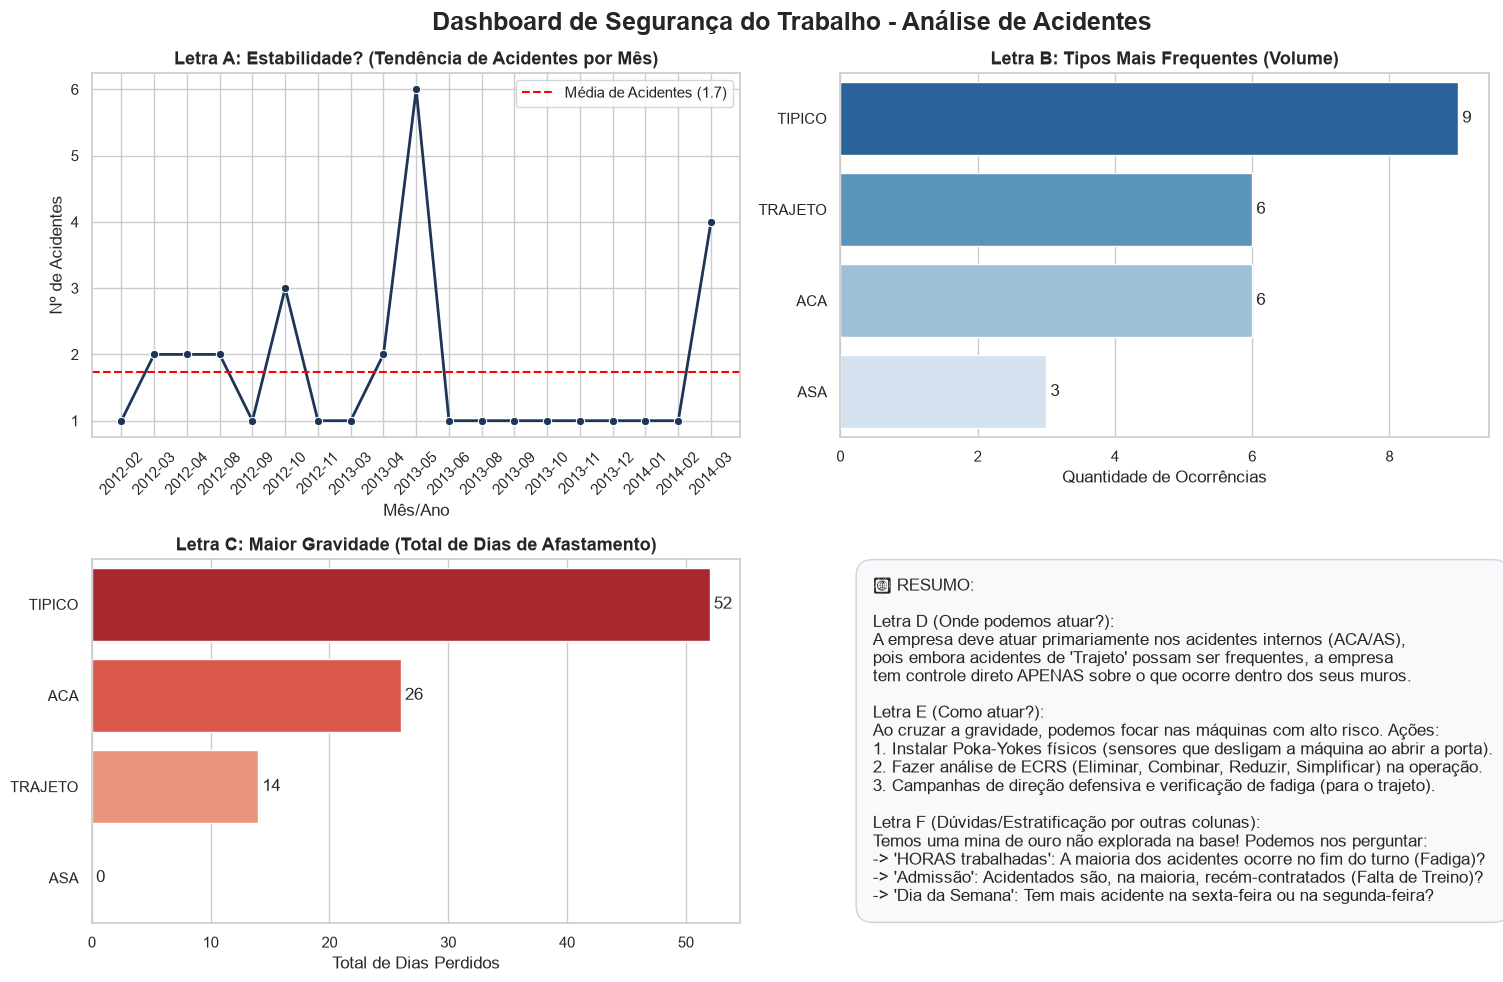

In [7]:
# TRATAMENTO E AGRUPAMENTO DE DADOS
# ====================================================================
# Garantir que a coluna de dias perdidos é tratada como número (preenchendo vazios com 0)
df['DIAS perdidos'] = pd.to_numeric(df['DIAS perdidos'], errors='coerce').fillna(0)

# Garantir que a data do acidente seja do tipo datetime (para agruparmos por mês)
df['DATA do acidente'] = pd.to_datetime(df['DATA do acidente'], errors='coerce')
# Criando a coluna de Ano-Mês para a linha do tempo (Ex: '2012-02')
df['Mes_Ano'] = df['DATA do acidente'].dt.to_period('M').astype(str)

# Letra A: Tendência (Total de acidentes por mês)
acidentes_por_mes = df.groupby('Mes_Ano').size().reset_index(name='Total_Acidentes')
media_acidentes = acidentes_por_mes['Total_Acidentes'].mean()

# Letra B: Frequência (Tipos de Acidente que mais ocorrem)
frequencia_tipos = df['TIPO de acidente'].value_counts().reset_index()
frequencia_tipos.columns = ['TIPO de acidente', 'Quantidade']

# Letra C: Gravidade (Dias perdidos somados por Tipo de Acidente)
gravidade_tipos = df.groupby('TIPO de acidente')['DIAS perdidos'].sum().reset_index()
gravidade_tipos = gravidade_tipos.sort_values(by='DIAS perdidos', ascending=False)




sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Dashboard de Segurança do Trabalho - Análise de Acidentes', fontsize=18, fontweight='bold')

# --- Gráfico 1 (Letra A): Tendência de acidentes no tempo ---
sns.lineplot(data=acidentes_por_mes, x='Mes_Ano', y='Total_Acidentes', marker='o', color='#1d3557', linewidth=2, ax=axes[0, 0])
axes[0, 0].axhline(media_acidentes, color='red', linestyle='--', label=f'Média de Acidentes ({media_acidentes:.1f})')
axes[0, 0].set_title('Letra A: Estabilidade? (Tendência de Acidentes por Mês)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Nº de Acidentes')
axes[0, 0].set_xlabel('Mês/Ano')
axes[0, 0].tick_params(axis='x', rotation=45) # Inclina as datas para não encavalarem
axes[0, 0].legend()

# --- Gráfico 2 (Letra B): Frequência por Tipo de Acidente ---
sns.barplot(data=frequencia_tipos, x='Quantidade', y='TIPO de acidente', palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title('Letra B: Tipos Mais Frequentes (Volume)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Quantidade de Ocorrências')
axes[0, 1].set_ylabel('')
# Rótulos nas barras
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, padding=3)

# --- Gráfico 3 (Letra C): Dias Perdidos por Tipo de Acidente (Gravidade) ---
sns.barplot(data=gravidade_tipos, x='DIAS perdidos', y='TIPO de acidente', palette='Reds_r', ax=axes[1, 0])
axes[1, 0].set_title('Letra C: Maior Gravidade (Total de Dias de Afastamento)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Total de Dias Perdidos')
axes[1, 0].set_ylabel('')
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, padding=3)

# --- Painel Analítico (Letras D, E, F) ---
axes[1, 1].axis('off') # Remove as linhas para virar um painel de texto
conclusao_texto = (
    "🎯 RESUMO:\n\n"
    "Letra D (Onde podemos atuar?):\n"
    "A empresa deve atuar primariamente nos acidentes internos (ACA/AS),\n"
    "pois embora acidentes de 'Trajeto' possam ser frequentes, a empresa\n"
    "tem controle direto APENAS sobre o que ocorre dentro dos seus muros.\n\n"
    "Letra E (Como atuar?):\n"
    "Ao cruzar a gravidade, podemos focar nas máquinas com alto risco. Ações:\n"
    "1. Instalar Poka-Yokes físicos (sensores que desligam a máquina ao abrir a porta).\n"
    "2. Fazer análise de ECRS (Eliminar, Combinar, Reduzir, Simplificar) na operação.\n"
    "3. Campanhas de direção defensiva e verificação de fadiga (para o trajeto).\n\n"
    "Letra F (Dúvidas/Estratificação por outras colunas):\n"
    "Temos uma mina de ouro não explorada na base! Podemos nos perguntar:\n"
    "-> 'HORAS trabalhadas': A maioria dos acidentes ocorre no fim do turno (Fadiga)?\n"
    "-> 'Admissão': Acidentados são, na maioria, recém-contratados (Falta de Treino)?\n"
    "-> 'Dia da Semana': Tem mais acidente na sexta-feira ou na segunda-feira?"
)
axes[1, 1].text(0.05, 0.5, conclusao_texto, fontsize=12, verticalalignment='center', 
                bbox=dict(boxstyle="round,pad=1", facecolor="#f8f9fa", edgecolor="#ced4da"))

plt.tight_layout()
plt.show()